Class distribution:
Sales_Class
2    32
0    32
1    30
Name: count, dtype: int64


C:\Users\jaweriya\anaconda3\ana\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:49:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Model Accuracy: 0.8947

Classification Report:
              precision    recall  f1-score   support

         Low       0.88      1.00      0.93         7
      Medium       1.00      0.67      0.80         6
        High       0.86      1.00      0.92         6

    accuracy                           0.89        19
   macro avg       0.91      0.89      0.89        19
weighted avg       0.91      0.89      0.89        19



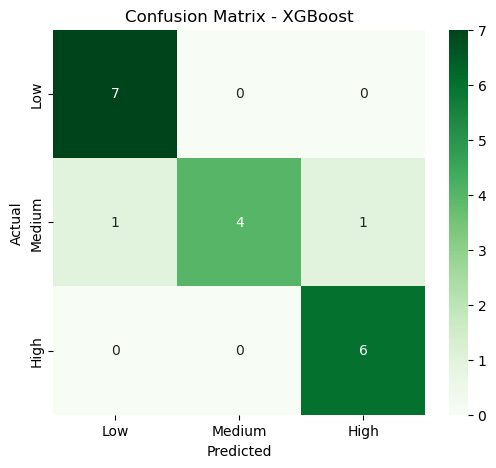


Sample Stock Alerts:
   May 2020  Predicted_Class   Stock_Alert
1  507477.0                2  Urgent Alert
2  399076.0                2  Urgent Alert
3  476072.0                2  Urgent Alert
4  367671.0                2  Urgent Alert
5  465086.0                2  Urgent Alert


In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 2: Load dataset
df = pd.read_excel("mrtssales92-present.xls")

# Step 2b: Clean column names
df.columns = df.columns.str.replace('.', '', regex=False).str.strip()

# Step 3: Identify monthly sales columns
month_cols = [col for col in df.columns if col.split()[0] in
              ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']]

# Step 4: Clean sales columns
for col in month_cols:
    df[col] = df[col].astype(str).str.replace(',', '').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=month_cols)

# Step 5: Encode NAICS Code
df['NAICS  Code'] = df['NAICS  Code'].astype(str).str.replace(',', '').str.strip()
le_code = LabelEncoder()
df['NAICS_Code_Encoded'] = le_code.fit_transform(df['NAICS  Code'])

# Step 6: Feature Engineering
# Historical columns (exclude 2020)
historical_cols = [col for col in month_cols if '2020' not in col]

# Mean, std, total sales
df['Sales_Mean_Historical'] = df[historical_cols].mean(axis=1)
df['Sales_Std_Historical'] = df[historical_cols].std(axis=1)
df['Total_Historical'] = df[historical_cols].sum(axis=1)

# Rolling averages for last 3 and 5 Mays
may_cols = sorted([col for col in historical_cols if 'May' in col])
if len(may_cols) >= 3:
    df['May_Rolling3'] = df[may_cols[-3:]].mean(axis=1)
if len(may_cols) >= 5:
    df['May_Rolling5'] = df[may_cols[-5:]].mean(axis=1)

# Growth from previous Mays
for i in range(1, len(may_cols)):
    df[f'May_Growth_{i}'] = df[may_cols[i]] / df[may_cols[i-1]]

# 2020 recent months
recent_2020 = ['Jan 2020','Feb 2020','Mar 2020','Apr 2020']

# Month-over-month growth for 2020
prev_month = None
for month in recent_2020:
    if prev_month:
        df[f'{month}_Growth'] = df[month] / df[prev_month]
    prev_month = month

# Step 7: Target variable - Sales_Class (May 2020)
df['Sales_Class'] = pd.qcut(df['May 2020'], q=3, labels=[0,1,2])
df['Sales_Class'] = df['Sales_Class'].astype(int)

print("Class distribution:")
print(df['Sales_Class'].value_counts())

# Step 8: Prepare features
feature_cols = recent_2020 + ['NAICS_Code_Encoded',
                              'Sales_Mean_Historical','Sales_Std_Historical','Total_Historical']

# Add rolling May averages if they exist
for col in ['May_Rolling3','May_Rolling5']:
    if col in df.columns:
        feature_cols.append(col)

# Add May growth features
may_growth_cols = [col for col in df.columns if 'May_Growth_' in col]
feature_cols += may_growth_cols

# Add 2020 monthly growth features
month_growth_cols = [col for col in df.columns if '_Growth' in col and 'May' not in col]
feature_cols += month_growth_cols

X = df[feature_cols]
y = df['Sales_Class']

# Step 9: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Step 10: XGBoost classifier (tuned)
model = XGBClassifier(
    n_estimators=800,
    max_depth=12,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
model.fit(X_train, y_train)

# Step 11: Predictions
y_pred = model.predict(X_test)

# Step 12: Evaluation
acc = accuracy_score(y_test, y_pred)
print(f"\n Model Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low','Medium','High'], zero_division=0))

# Step 13: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low','Medium','High'],
            yticklabels=['Low','Medium','High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

# Step 14: Stock Alerts
df['Predicted_Class'] = model.predict(X)
df['Stock_Alert'] = df['Predicted_Class'].map({0: 'No Alert', 1: 'Check Stock', 2: 'Urgent Alert'})

print("\nSample Stock Alerts:")
print(df[['May 2020','Predicted_Class','Stock_Alert']].head())
